# **Results & Performance Analysis**

This notebook consolidates the results from:
- **Queries** 
- **ML predictions** (5 different regression models trained on two targets: `total_amount` and `trip_duration_min`)

across **8 different Spark configurations** (`baseline`, `balanced`, `high_parallelism`, `memory_optimized`, `stress_test`, `low_overhead`, `aqe_only`, `cpu_heavy`).

---

## **1. Setup**

### **1.1. Libraries**

In [6]:
import os
import json
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns

warnings.filterwarnings("ignore")

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# Consistent color palette for the 8 Spark scenarios
SCENARIO_ORDER = [
    "baseline", "balanced", "high_parallelism", "memory_optimized",
    "stress_test", "low_overhead", "aqe_only", "cpu_heavy"
]
SCENARIO_PALETTE = dict(zip(SCENARIO_ORDER, sns.color_palette("tab10", n_colors=8)))

# Consistent palette for ML models (filled in dynamically once data is loaded)
MODEL_PALETTE = {}


### **1.2. Paths**

In [7]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR  = "data/results/models"

# Optional artifacts for the post-modeling section (Section 7).
# Generated by running prediction_luana.ipynb with the export block enabled.
ARTIFACTS_DIR = "data/results/artifacts"
PREDICTIONS_SAMPLE_PATH       = os.path.join(ARTIFACTS_DIR, "predictions_sample.parquet")
FEATURE_IMPORTANCE_AMOUNT_PATH = os.path.join(ARTIFACTS_DIR, "feature_importance_total_amount.csv")
FEATURE_IMPORTANCE_DURATION_PATH = os.path.join(ARTIFACTS_DIR, "feature_importance_trip_duration.csv")


## **2. Load & Consolidate Results**

All JSON result files are loaded into two long-format DataFrames:
- `df_queries`: one row per (run, query)
- `df_models`: one row per (run, model, target)

Each row also carries the Spark configuration of that run.

### **2.1. Queries**

In [8]:
queries_rows = []

for file_name in sorted(os.listdir(QUERIES_DIR)):
    if not file_name.endswith(".json"):
        continue

    file_path = os.path.join(QUERIES_DIR, file_name)
    # Author name extracted from the filename: results_<author>.json
    author = file_name.replace("results_", "").replace(".json", "")

    with open(file_path, "r") as f:
        data = json.load(f)

    for run in data.get("runs", []):
        cfg = run.get("spark_config", {})
        base_info = {
            "author": author,
            "timestamp": run.get("timestamp"),
            "spark_mode": run.get("spark_mode"),
            "executor_instances": cfg.get("executor_instances"),
            "executor_cores": cfg.get("executor_cores"),
            "executor_memory": cfg.get("executor_memory"),
            "shuffle_partitions": cfg.get("shuffle_partitions"),
            "adaptive": cfg.get("adaptive"),
        }
        for metric in run.get("metrics", []):
            queries_rows.append({
                **base_info,
                "query_description": metric.get("Query Description"),
                "api_time_s": metric.get("API Time (s)"),
                "sql_time_s": metric.get("SQL Time (s)"),
                "time_delta": metric.get("Time Delta (SQL - API)"),
            })

df_queries = pd.DataFrame(queries_rows)
df_queries["timestamp"] = pd.to_datetime(df_queries["timestamp"], errors="coerce")

# Derived: total parallelism (total vCores available across the cluster)
df_queries["total_cores"] = df_queries["executor_instances"] * df_queries["executor_cores"]
# Derived: which is faster, API or SQL
df_queries["faster_engine"] = np.where(df_queries["sql_time_s"] < df_queries["api_time_s"], "SQL", "API")

print(f"Loaded {len(df_queries)} query rows from {df_queries['author'].nunique()} authors")
print(f"Scenarios covered: {sorted(df_queries['spark_mode'].dropna().unique())}")
df_queries.head()

Loaded 899 query rows from 4 authors
Scenarios covered: ['aqe_only', 'balanced', 'baseline', 'cpu_heavy', 'high_parallelism', 'low_overhead', 'memory_optimized', 'stress_test']


,author,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,query_description,api_time_s,sql_time_s,time_delta,total_cores,faster_engine
0,leonor,2026-05-17 17:16:55,baseline,2,1,3g,50,False,Q1.1: Borough Revenue vs Tip Percentage,5.0557,7.2595,2.2038,2,API
1,leonor,2026-05-17 17:16:55,baseline,2,1,3g,50,False,Q1.2: Tip Paradox by Distance,5.3696,4.5349,-0.8347,2,SQL
2,leonor,2026-05-17 17:16:55,baseline,2,1,3g,50,False,Q1.3: Revenue Composition,1.2454,1.0311,-0.2144,2,SQL
3,leonor,2026-05-17 17:16:55,baseline,2,1,3g,50,False,Q1.4: Payment Method Impact,4.2541,3.8913,-0.3628,2,SQL
4,leonor,2026-05-17 17:16:55,baseline,2,1,3g,50,False,Q1.5: Passenger Count Impact,4.5645,4.2312,-0.3333,2,SQL


### **2.2. Models**

In [9]:
models_rows = []

for file_name in sorted(os.listdir(MODELS_DIR)):
    if not file_name.endswith(".json"):
        continue

    file_path = os.path.join(MODELS_DIR, file_name)
    # Author name: models_results_<author>.json
    author = file_name.replace("models_results_", "").replace(".json", "")

    with open(file_path, "r") as f:
        data = json.load(f)

    for run in data.get("runs", []):
        cfg = run.get("spark_config", {})
        base_info = {
            "author": author,
            "timestamp": run.get("timestamp"),
            "spark_mode": run.get("spark_mode"),
            "executor_instances": cfg.get("executor_instances"),
            "executor_cores": cfg.get("executor_cores"),
            "executor_memory": cfg.get("executor_memory"),
            "shuffle_partitions": cfg.get("shuffle_partitions"),
            "adaptive": cfg.get("adaptive"),
        }
        for result in run.get("model_results", []):
            metrics = result.get("metrics", {})
            models_rows.append({
                **base_info,
                "model_name": result.get("model_name"),
                "target": result.get("target"),
                "task_type": result.get("task_type"),
                "rmse": metrics.get("rmse"),
                "r2": metrics.get("r2"),
                "mae": metrics.get("mae"),
                "mse": metrics.get("mse"),
                "execution_time_seconds": result.get("execution_time_seconds"),
            })

df_models = pd.DataFrame(models_rows)
df_models["timestamp"] = pd.to_datetime(df_models["timestamp"], errors="coerce")
df_models["total_cores"] = df_models["executor_instances"] * df_models["executor_cores"]

# Assign a consistent color per model for all plots
unique_models = sorted(df_models["model_name"].dropna().unique())
MODEL_PALETTE.update(dict(zip(unique_models, sns.color_palette("Set2", n_colors=len(unique_models)))))

print(f"Loaded {len(df_models)} model-target rows")
print(f"Models found: {unique_models}")
print(f"Targets: {sorted(df_models['target'].dropna().unique())}")
df_models.head()

Loaded 68 model-target rows
Models found: ['DecisionTreeRegressor', 'GBTRegressor', 'GeneralizedLinearModel', 'LinearRegression_Ridge_Std', 'RandomForestRegressor']
Targets: ['total_amount', 'trip_duration_min']


,author,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,model_name,target,task_type,rmse,r2,mae,mse,execution_time_seconds,total_cores
0,iara,2026-05-16 16:29:08,baseline,2,1,3g,50,False,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,623.91,2
1,iara,2026-05-16 16:29:08,baseline,2,1,3g,50,False,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,506.73,2
2,iara,2026-05-16 17:06:30,balanced,2,2,4g,100,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,496.94,4
3,iara,2026-05-16 17:06:30,balanced,2,2,4g,100,True,LinearRegression_Ridge_Std,trip_duration_min,regression,4.0208,0.8396,2.3487,16.1668,496.84,4
4,iara,2026-05-16 17:28:00,high_parallelism,3,2,4g,150,True,LinearRegression_Ridge_Std,total_amount,regression,2.2880,0.9662,1.2109,5.2348,494.11,6


### **2.3. Sanity check — coverage matrix**

Before analyzing, we verify which (author × scenario) combinations actually produced data. Empty cells mean that combination wasn't run (e.g. `cpu_heavy` failed for everyone because it requests `executor_cores=3`, exceeding `yarn.scheduler.maximum-allocation-vcores=2` on `n2-standard-2` workers).

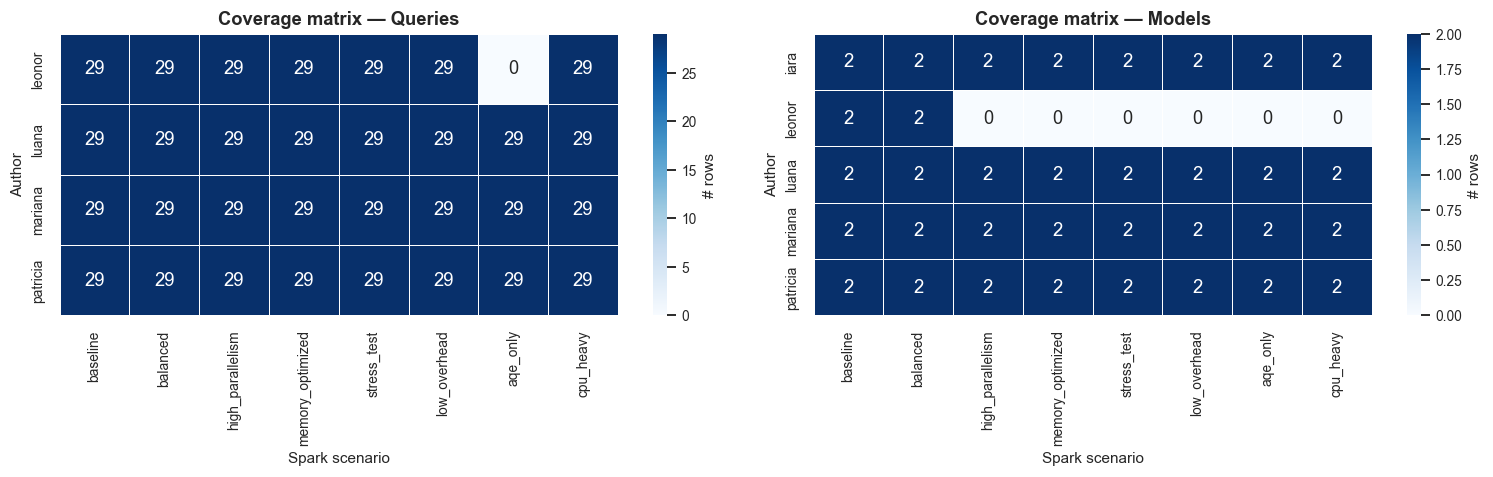

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for ax, (df, title) in zip(axes, [(df_queries, "Queries"), (df_models, "Models")]):
    coverage = (
        df.groupby(["author", "spark_mode"])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=[s for s in SCENARIO_ORDER if s in df["spark_mode"].unique()])
    )
    sns.heatmap(
        coverage, annot=True, fmt="d", cmap="Blues",
        cbar_kws={"label": "# rows"}, ax=ax, linewidths=0.5, linecolor="white"
    )
    ax.set_title(f"Coverage matrix — {title}")
    ax.set_xlabel("Spark scenario")
    ax.set_ylabel("Author")

plt.tight_layout()
plt.show()

## **3. Scenario Profiling**

Before looking at performance, we characterize the 8 Spark configurations we tested. Each scenario probes a different aspect of Spark tuning:

| Scenario | Hypothesis being tested |
|---|---|
| `baseline` | Conservative reference point — minimal resources, no AQE |
| `balanced` | Moderate parallelism with AQE enabled |
| `high_parallelism` | More executors and partitions to maximize task-level concurrency |
| `memory_optimized` | Trade cores for memory per executor |
| `stress_test` | Many small executors with high shuffle partitions |
| `low_overhead` | Few large partitions, AQE off — minimizes scheduling overhead |
| `aqe_only` | Same as baseline but with Adaptive Query Execution ON — isolates AQE's effect |
| `cpu_heavy` | More cores per executor (limited by `yarn.scheduler.maximum-allocation-vcores`) |

In [11]:
# Build a one-row-per-scenario summary
scenario_cfg = (
    df_queries.dropna(subset=["spark_mode"])
              .groupby("spark_mode")
              .agg(
                  executor_instances=("executor_instances", "first"),
                  executor_cores=("executor_cores", "first"),
                  executor_memory=("executor_memory", "first"),
                  shuffle_partitions=("shuffle_partitions", "first"),
                  adaptive=("adaptive", "first"),
                  total_cores=("total_cores", "first"),
              )
              .reindex([s for s in SCENARIO_ORDER if s in df_queries["spark_mode"].unique()])
)
scenario_cfg

,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,total_cores
spark_mode,,,,,,
baseline,2,1,3g,50,False,2
balanced,2,2,4g,100,True,4
high_parallelism,3,2,4g,150,True,6
memory_optimized,2,1,6g,100,True,2
stress_test,4,2,3g,200,True,8
low_overhead,2,2,4g,25,False,4
aqe_only,2,1,3g,50,True,2
cpu_heavy,3,3,3g,150,True,9


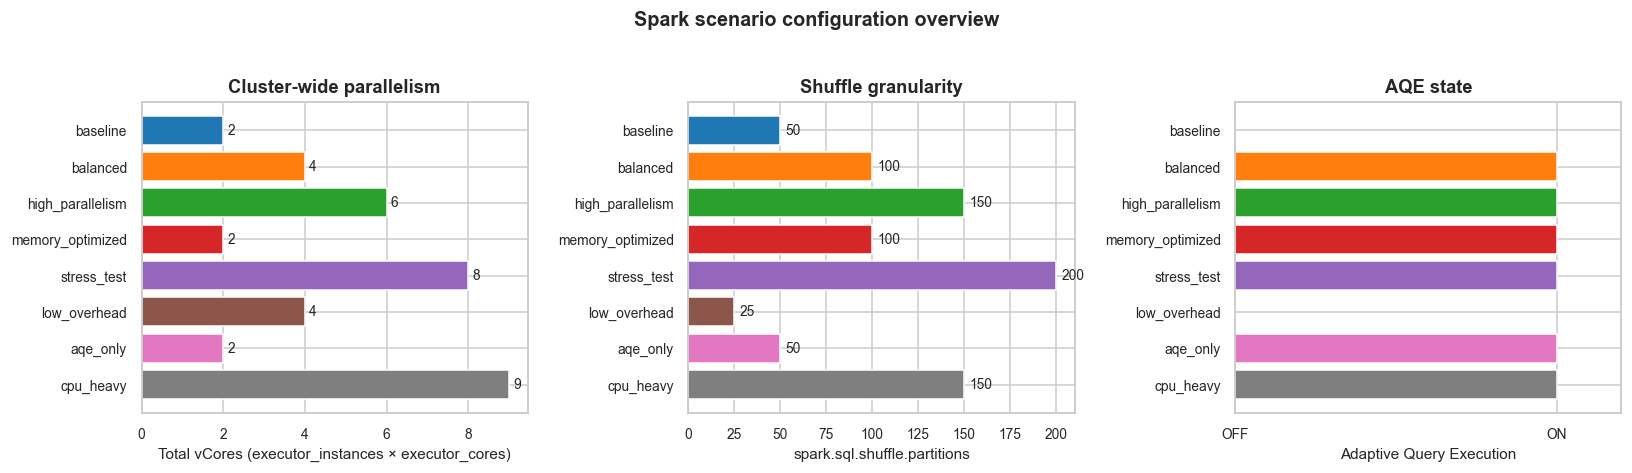

In [12]:
# Visualize the configuration space — what each scenario looks like
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

scenarios = scenario_cfg.index.tolist()
colors = [SCENARIO_PALETTE[s] for s in scenarios]

# (a) total cores per scenario
axes[0].barh(scenarios, scenario_cfg["total_cores"], color=colors, edgecolor="white")
axes[0].set_xlabel("Total vCores (executor_instances × executor_cores)")
axes[0].set_title("Cluster-wide parallelism")
axes[0].invert_yaxis()
for i, v in enumerate(scenario_cfg["total_cores"]):
    axes[0].text(v + 0.1, i, str(int(v)), va="center", fontsize=9)

# (b) shuffle partitions
axes[1].barh(scenarios, scenario_cfg["shuffle_partitions"], color=colors, edgecolor="white")
axes[1].set_xlabel("spark.sql.shuffle.partitions")
axes[1].set_title("Shuffle granularity")
axes[1].invert_yaxis()
for i, v in enumerate(scenario_cfg["shuffle_partitions"]):
    axes[1].text(v + 3, i, str(int(v)), va="center", fontsize=9)

# (c) adaptive on/off
adaptive_int = scenario_cfg["adaptive"].astype(int)
axes[2].barh(scenarios, adaptive_int, color=colors, edgecolor="white")
axes[2].set_xlim(0, 1.2)
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["OFF", "ON"])
axes[2].set_xlabel("Adaptive Query Execution")
axes[2].set_title("AQE state")
axes[2].invert_yaxis()

plt.suptitle("Spark scenario configuration overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## **4. Spark Performance — Analytical Queries**

We measured each analytical query's execution time using **two engines**:
- **API** — DataFrame API (Python, lazy-evaluated)
- **SQL** — Spark SQL string queries

For each scenario, we have multiple queries. We aggregate by scenario to get a representative cost per configuration.

### **4.1. Total execution time per scenario**

The first question: which scenario is fastest *overall*? We sum the times of all queries within each run (one bar per author × scenario), then average across authors.

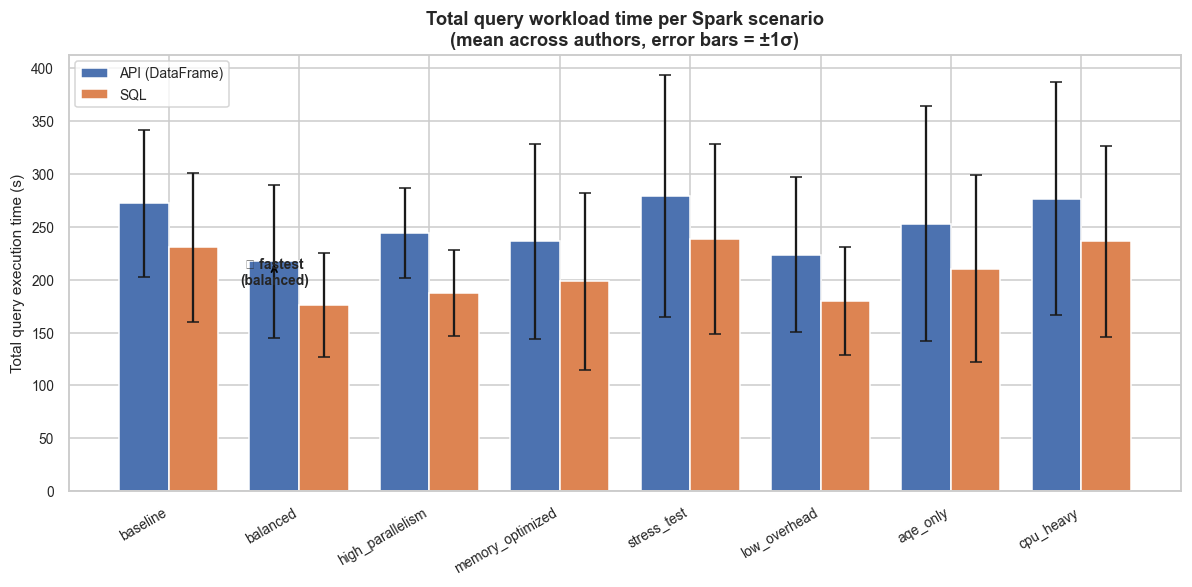


Numerical summary (seconds):
                  api_mean  api_std  sql_mean  sql_std  n_runs
spark_mode                                                    
baseline            272.45    69.42    230.56    70.65       4
balanced            217.26    72.32    176.18    49.59       4
high_parallelism    244.05    42.57    187.62    40.50       4
memory_optimized    236.23    91.81    198.40    83.69       4
stress_test         279.24   114.05    238.46    89.76       4
low_overhead        223.85    73.65    180.04    50.95       4
aqe_only            253.00   111.18    210.31    88.51       3
cpu_heavy           276.75   109.79    236.48    90.34       4


In [13]:
# Total wall-clock time per (author, scenario) run, separately for API and SQL
totals = (
    df_queries.groupby(["author", "spark_mode"])
              .agg(api_total=("api_time_s", "sum"),
                   sql_total=("sql_time_s", "sum"),
                   n_queries=("query_description", "count"))
              .reset_index()
)

# Average across authors per scenario (with std for error bars)
scenario_summary = (
    totals.groupby("spark_mode")
          .agg(api_mean=("api_total", "mean"),
               api_std=("api_total", "std"),
               sql_mean=("sql_total", "mean"),
               sql_std=("sql_total", "std"),
               n_runs=("author", "count"))
          .reindex([s for s in SCENARIO_ORDER if s in totals["spark_mode"].unique()])
)

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(scenario_summary))
w = 0.38

bars1 = ax.bar(x - w/2, scenario_summary["api_mean"], w,
               yerr=scenario_summary["api_std"], capsize=4,
               label="API (DataFrame)", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + w/2, scenario_summary["sql_mean"], w,
               yerr=scenario_summary["sql_std"], capsize=4,
               label="SQL", color="#DD8452", edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(scenario_summary.index, rotation=30, ha="right")
ax.set_ylabel("Total query execution time (s)")
ax.set_title("Total query workload time per Spark scenario\n(mean across authors, error bars = ±1σ)")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

# Annotate the fastest scenario
fastest_idx = scenario_summary["api_mean"].idxmin()
fastest_pos = list(scenario_summary.index).index(fastest_idx)
ax.annotate(f"★ fastest\n({fastest_idx})",
            xy=(fastest_pos - w/2, scenario_summary.loc[fastest_idx, "api_mean"]),
            xytext=(fastest_pos - w/2, scenario_summary["api_mean"].max() * 0.7),
            ha="center", fontsize=9, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.2))

plt.tight_layout()
plt.show()

print("\nNumerical summary (seconds):")
print(scenario_summary.round(2))

### **4.2. API vs SQL — does the engine matter?**

For the same logical query, is one engine systematically faster? Catalyst (Spark's optimizer) processes both, but expressed differently.

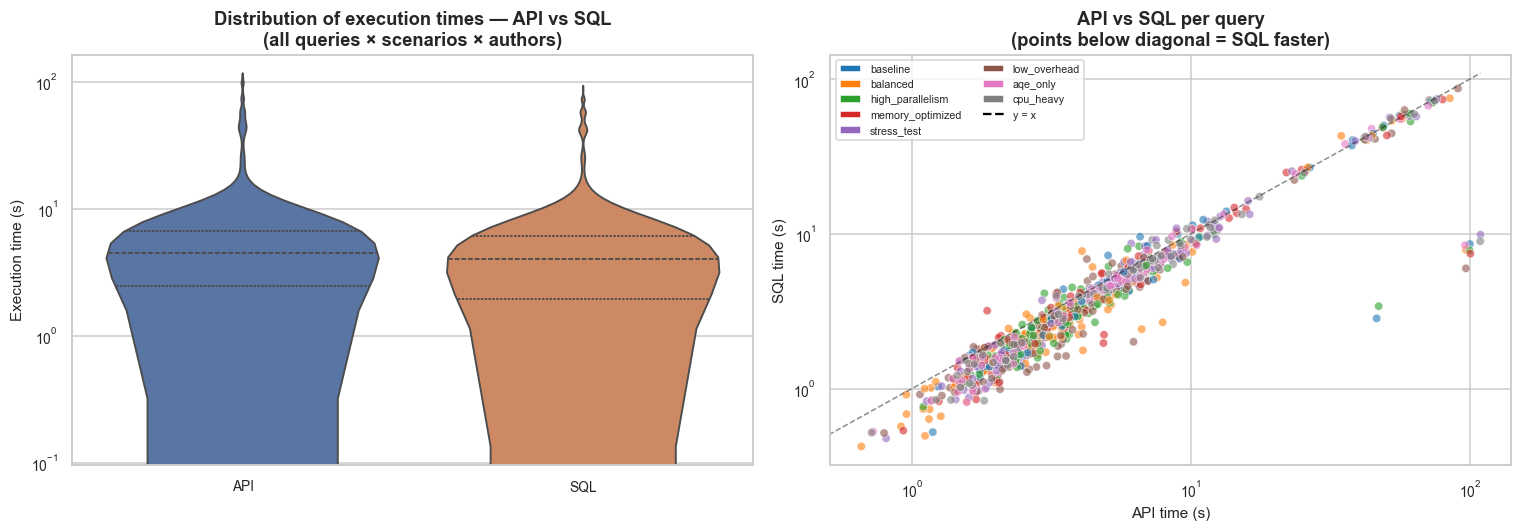


% of (query × scenario) cases where SQL was faster than API: 86.7%
Mean time delta (SQL - API): -1.487s


In [14]:
# Per-query comparison, aggregated across all scenarios and authors
api_sql_long = (
    df_queries.melt(
        id_vars=["author", "spark_mode", "query_description"],
        value_vars=["api_time_s", "sql_time_s"],
        var_name="engine", value_name="time_s"
    )
    .assign(engine=lambda d: d["engine"].map({"api_time_s": "API", "sql_time_s": "SQL"}))
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of times, API vs SQL
sns.violinplot(data=api_sql_long, x="engine", y="time_s",
               palette=["#4C72B0", "#DD8452"], inner="quartile", ax=axes[0])
axes[0].set_ylabel("Execution time (s)")
axes[0].set_xlabel("")
axes[0].set_title("Distribution of execution times — API vs SQL\n(all queries × scenarios × authors)")
axes[0].set_yscale("log")

# (b) Scatter: each point is one query in one scenario
scatter_df = df_queries.dropna(subset=["api_time_s", "sql_time_s"])
axes[1].scatter(scatter_df["api_time_s"], scatter_df["sql_time_s"],
                c=[SCENARIO_PALETTE.get(s, "#888") for s in scatter_df["spark_mode"]],
                alpha=0.6, s=30, edgecolor="white", linewidth=0.5)

# Diagonal y=x line
lim = max(scatter_df["api_time_s"].max(), scatter_df["sql_time_s"].max())
axes[1].plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="y = x (equal time)")

axes[1].set_xlabel("API time (s)")
axes[1].set_ylabel("SQL time (s)")
axes[1].set_title("API vs SQL per query\n(points below diagonal = SQL faster)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

# Custom legend for scenarios
handles = [Patch(facecolor=SCENARIO_PALETTE[s], label=s)
           for s in SCENARIO_ORDER if s in scatter_df["spark_mode"].unique()]
handles.append(Line2D([0], [0], color="black", linestyle="--", label="y = x"))
axes[1].legend(handles=handles, loc="upper left", fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\n% of (query × scenario) cases where SQL was faster than API: "
      f"{(scatter_df['sql_time_s'] < scatter_df['api_time_s']).mean()*100:.1f}%")
print(f"Mean time delta (SQL - API): {(scatter_df['sql_time_s'] - scatter_df['api_time_s']).mean():.3f}s")

### **4.3. Query-level breakdown**

Which queries dominate the total time? A few heavy queries usually drive the overall cost.

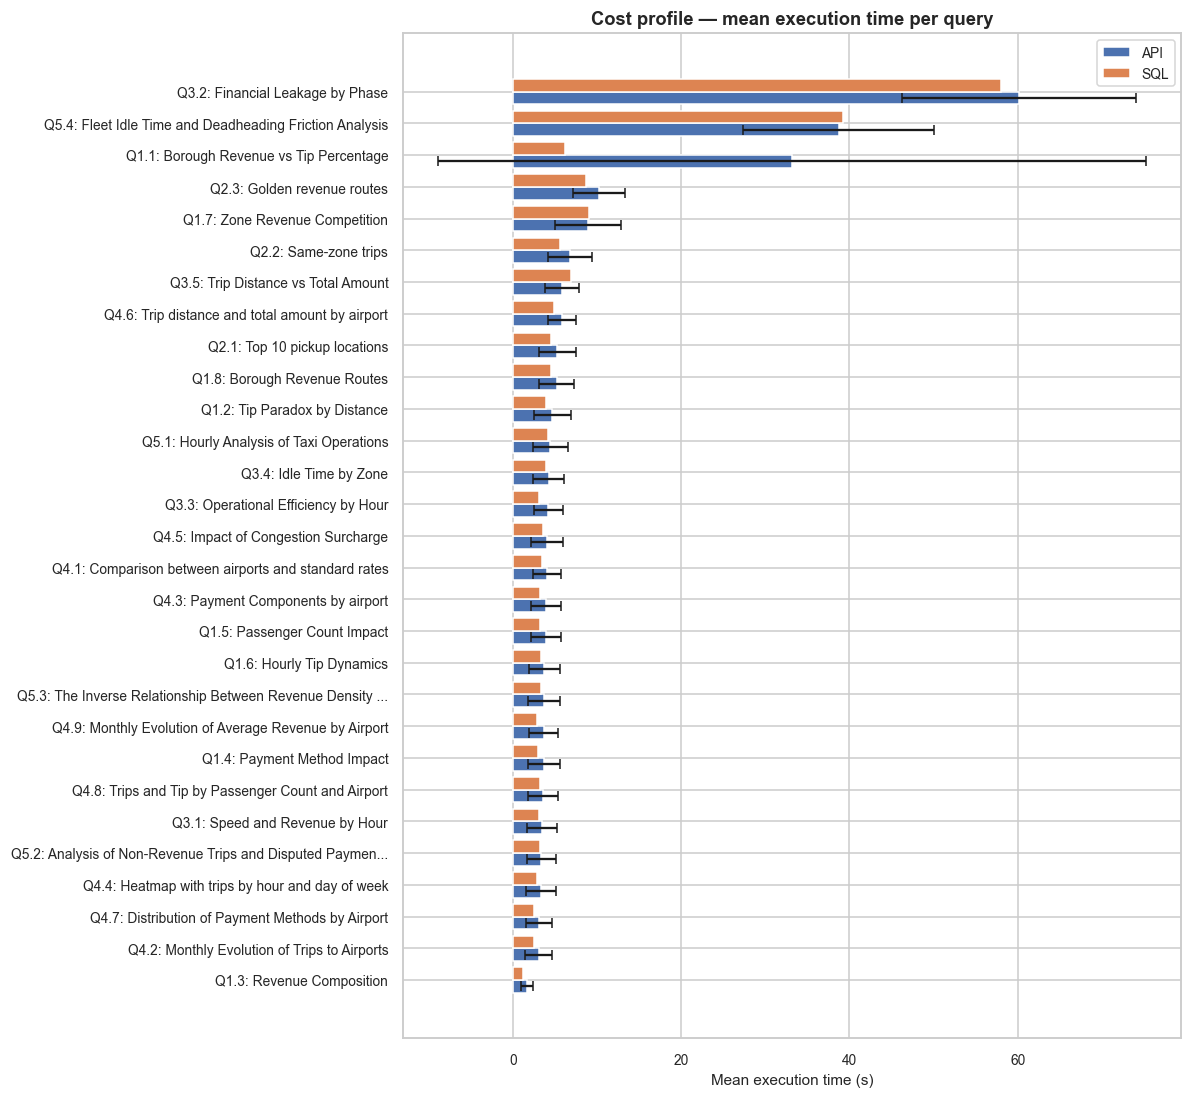

In [15]:
# Average API time per query across all scenarios and authors
query_costs = (
    df_queries.groupby("query_description")
              .agg(mean_api=("api_time_s", "mean"),
                   std_api=("api_time_s", "std"),
                   mean_sql=("sql_time_s", "mean"),
                   n_obs=("author", "count"))
              .sort_values("mean_api", ascending=True)
)

# Truncate long descriptions for the plot
query_costs.index = [
    (d[:55] + "...") if isinstance(d, str) and len(d) > 55 else d
    for d in query_costs.index
]

fig, ax = plt.subplots(figsize=(11, max(4, 0.35 * len(query_costs))))
y_pos = np.arange(len(query_costs))
w = 0.4

ax.barh(y_pos - w/2, query_costs["mean_api"], w, xerr=query_costs["std_api"],
        label="API", color="#4C72B0", capsize=3, edgecolor="white")
ax.barh(y_pos + w/2, query_costs["mean_sql"], w,
        label="SQL", color="#DD8452", capsize=3, edgecolor="white")

ax.set_yticks(y_pos)
ax.set_yticklabels(query_costs.index)
ax.set_xlabel("Mean execution time (s)")
ax.set_title("Cost profile — mean execution time per query")
ax.legend()
plt.tight_layout()
plt.show()

### **4.4. Isolating AQE — `baseline` vs `aqe_only`**

The `aqe_only` scenario is identical to `baseline` except for `spark.sql.adaptive.enabled=true`. This is a controlled experiment for AQE's effect.

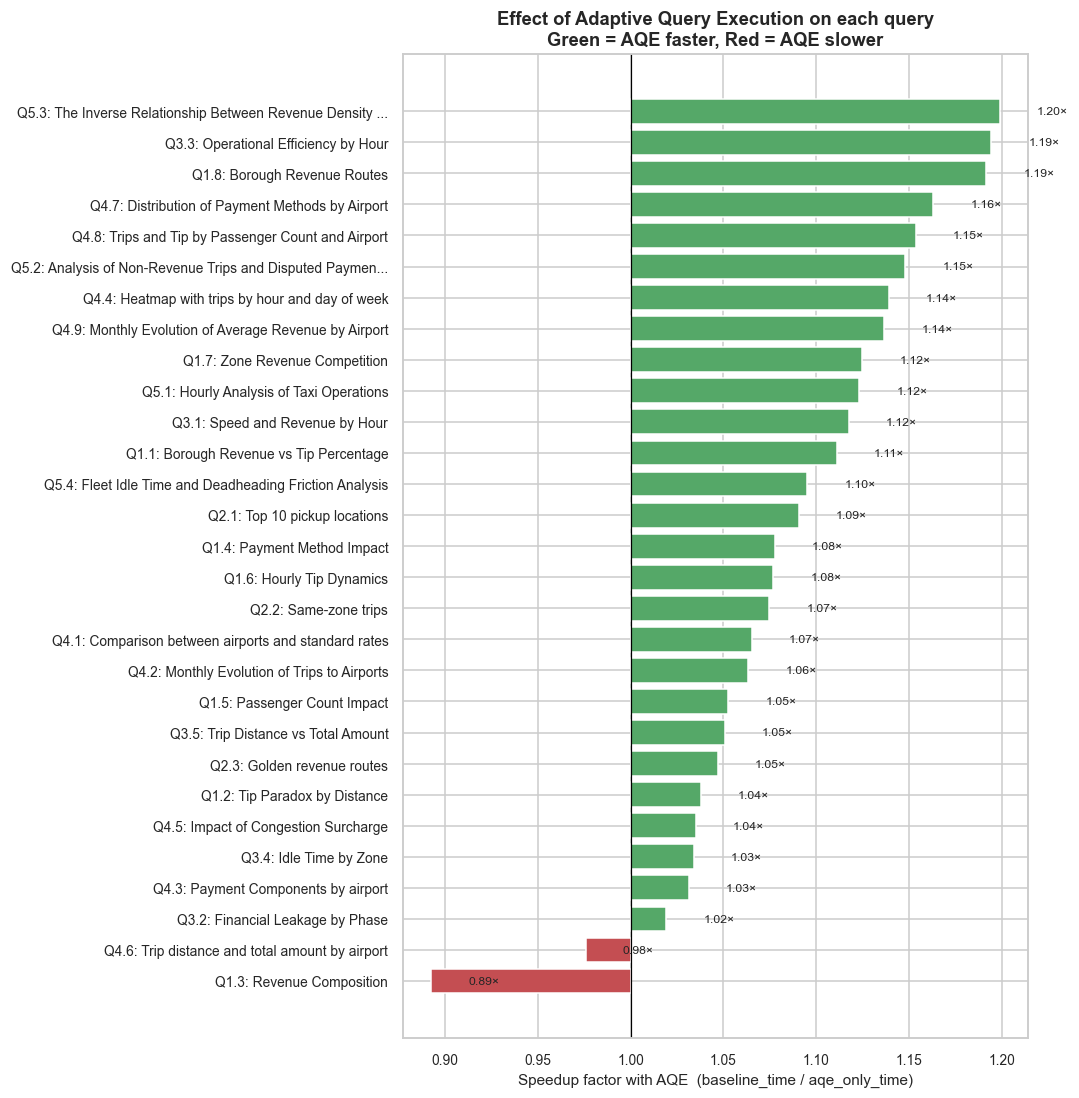


Mean speedup from AQE: 1.087×
AQE helped on 27 of 29 queries


In [16]:
aqe_compare = (
    df_queries[df_queries["spark_mode"].isin(["baseline", "aqe_only"])]
    .groupby(["spark_mode", "query_description"])
    .agg(api_mean=("api_time_s", "mean"), sql_mean=("sql_time_s", "mean"))
    .reset_index()
)

# Pivot so each query becomes a single row with baseline and aqe columns
aqe_pivot = aqe_compare.pivot(
    index="query_description",
    columns="spark_mode",
    values="api_mean"
).dropna()

# Speedup = baseline / aqe_only  (>1 means AQE made it faster)
aqe_pivot["speedup_aqe"] = aqe_pivot["baseline"] / aqe_pivot["aqe_only"]
aqe_pivot = aqe_pivot.sort_values("speedup_aqe")

# Truncate descriptions for plot readability
aqe_pivot.index = [
    (d[:55] + "...") if isinstance(d, str) and len(d) > 55 else d
    for d in aqe_pivot.index
]

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(aqe_pivot))))
colors = ["#C44E52" if v < 1 else "#55A868" for v in aqe_pivot["speedup_aqe"]]
ax.barh(aqe_pivot.index, aqe_pivot["speedup_aqe"] - 1, color=colors,
        edgecolor="white", left=1)
ax.axvline(1, color="black", linewidth=0.8)
ax.set_xlabel("Speedup factor with AQE  (baseline_time / aqe_only_time)")
ax.set_title("Effect of Adaptive Query Execution on each query\n"
             "Green = AQE faster, Red = AQE slower")

# Annotate values
for i, v in enumerate(aqe_pivot["speedup_aqe"]):
    ax.text(v + 0.02, i, f"{v:.2f}×", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nMean speedup from AQE: {aqe_pivot['speedup_aqe'].mean():.3f}×")
print(f"AQE helped on {(aqe_pivot['speedup_aqe'] > 1).sum()} of {len(aqe_pivot)} queries")

## **5. Scaling Analysis — Speedup, Efficiency, Amdahl's Law**

The project brief explicitly asks for "*Runtime/performance using different number of computing nodes*". Our scenarios vary in `total_cores = executor_instances × executor_cores`, ranging from 2 to 8 cores.

We use the `baseline` scenario as the reference point (1× speedup) and compute:
- **Speedup**: S(p) = T(baseline) / T(p)
- **Parallel efficiency**: E(p) = S(p) / (p / p_baseline)
- **Estimated serial fraction** from Amdahl's Law: f = (1/S - 1/p) / (1 - 1/p)

### **5.1. Strong scaling — fixed workload, varying parallelism**

How does execution time decrease as we add cores to the same workload?

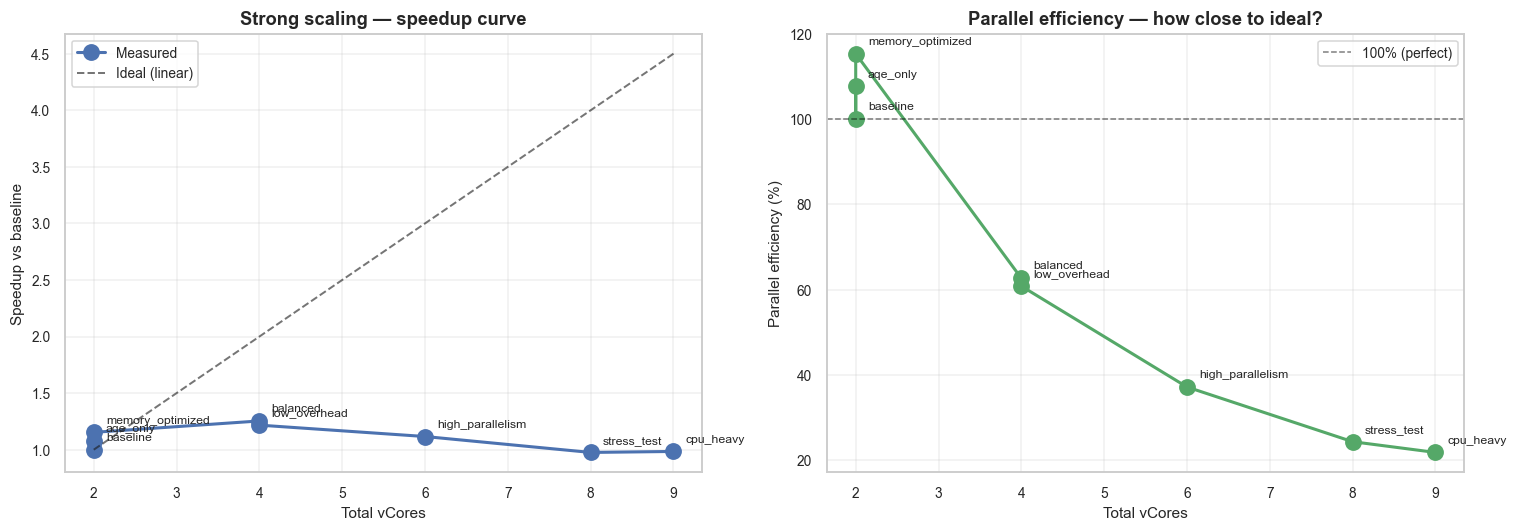


Scaling summary:
      spark_mode  total_cores  mean_time  speedup  efficiency
        aqe_only            2    253.004    1.077       1.077
        baseline            2    272.455    1.000       1.000
memory_optimized            2    236.233    1.153       1.153
        balanced            4    217.263    1.254       0.627
    low_overhead            4    223.853    1.217       0.609
high_parallelism            6    244.046    1.116       0.372
     stress_test            8    279.236    0.976       0.244
       cpu_heavy            9    276.753    0.984       0.219


In [17]:
# Use the total API time per (author, scenario) as the workload measurement
scaling = (
    totals.merge(scenario_cfg.reset_index(), on="spark_mode")
          .groupby(["spark_mode", "total_cores"])
          .agg(mean_time=("api_total", "mean"), std_time=("api_total", "std"))
          .reset_index()
          .sort_values("total_cores")
)

# Reference is baseline
T_baseline = scaling.loc[scaling["spark_mode"] == "baseline", "mean_time"].iloc[0]
p_baseline = scaling.loc[scaling["spark_mode"] == "baseline", "total_cores"].iloc[0]

scaling["speedup"] = T_baseline / scaling["mean_time"]
scaling["efficiency"] = scaling["speedup"] / (scaling["total_cores"] / p_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Speedup curve
axes[0].plot(scaling["total_cores"], scaling["speedup"], "o-",
             color="#4C72B0", markersize=10, lw=2, label="Measured")

# Ideal linear speedup
cores_range = np.linspace(scaling["total_cores"].min(), scaling["total_cores"].max(), 50)
ideal = cores_range / p_baseline
axes[0].plot(cores_range, ideal, "k--", lw=1.3, label="Ideal (linear)", alpha=0.6)

# Annotate each point with the scenario name
for _, row in scaling.iterrows():
    axes[0].annotate(row["spark_mode"],
                     (row["total_cores"], row["speedup"]),
                     xytext=(8, 6), textcoords="offset points", fontsize=8)

axes[0].set_xlabel("Total vCores")
axes[0].set_ylabel("Speedup vs baseline")
axes[0].set_title("Strong scaling — speedup curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (b) Parallel efficiency
axes[1].plot(scaling["total_cores"], scaling["efficiency"] * 100, "o-",
             color="#55A868", markersize=10, lw=2)
axes[1].axhline(100, color="black", linestyle="--", lw=1, alpha=0.5, label="100% (perfect)")

for _, row in scaling.iterrows():
    axes[1].annotate(row["spark_mode"],
                     (row["total_cores"], row["efficiency"] * 100),
                     xytext=(8, 6), textcoords="offset points", fontsize=8)

axes[1].set_xlabel("Total vCores")
axes[1].set_ylabel("Parallel efficiency (%)")
axes[1].set_title("Parallel efficiency — how close to ideal?")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nScaling summary:")
print(scaling[["spark_mode", "total_cores", "mean_time", "speedup", "efficiency"]].round(3).to_string(index=False))

### **5.2. Amdahl's Law — estimating the serial fraction**

Amdahl's Law states that the maximum achievable speedup is bounded by the fraction of work that *must* run serially. We can invert this to estimate the serial fraction `f` from the observed speedup:

$$ S(p) = \frac{1}{f + (1-f)/p} \quad \Longrightarrow \quad f = \frac{1/S - 1/p}{1 - 1/p} $$

A higher `f` means more inherent serialization (driver work, shuffles, scheduling overhead) and a lower asymptotic speedup ceiling.

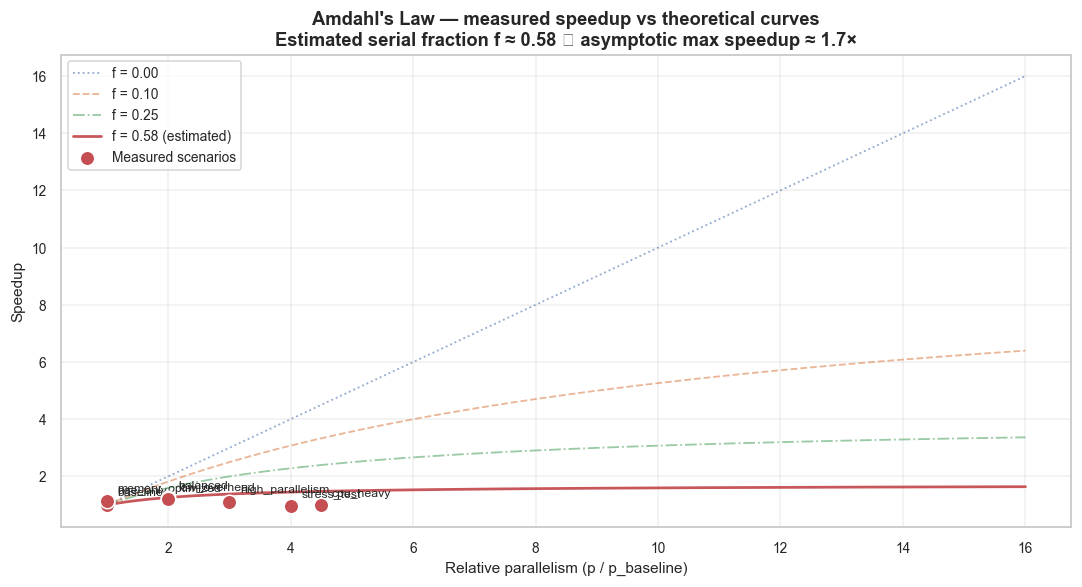


Estimated serial fraction f ≈ 0.583
This implies an asymptotic maximum speedup of ~1.7× regardless of how many cores we add.


In [18]:
# Compute the implied serial fraction for each scenario (vs baseline)
scaling_amdahl = scaling[scaling["spark_mode"] != "baseline"].copy()
p_norm = scaling_amdahl["total_cores"] / p_baseline   # normalized parallelism
s = scaling_amdahl["speedup"]

with np.errstate(divide="ignore", invalid="ignore"):
    f_serial = (1/s - 1/p_norm) / (1 - 1/p_norm)

scaling_amdahl["serial_fraction"] = f_serial

mean_f = scaling_amdahl["serial_fraction"].clip(0, 1).mean()

# Amdahl curves for several values of f
fig, ax = plt.subplots(figsize=(10, 5.5))

p_curve = np.linspace(1, 16, 200)
for f, ls in [(0.0, ":"), (0.1, "--"), (0.25, "-."), (mean_f, "-")]:
    s_curve = 1 / (f + (1 - f) / p_curve)
    label = f"f = {f:.2f}" + (" (estimated)" if abs(f - mean_f) < 1e-6 else "")
    ax.plot(p_curve, s_curve, ls, lw=1.8 if abs(f - mean_f) < 1e-6 else 1.2,
            label=label, alpha=0.95 if abs(f - mean_f) < 1e-6 else 0.6)

# Overlay measurements
ax.scatter(scaling["total_cores"] / p_baseline, scaling["speedup"],
           s=90, color="#C44E52", zorder=5, edgecolor="white",
           label="Measured scenarios")
for _, row in scaling.iterrows():
    ax.annotate(row["spark_mode"],
                (row["total_cores"] / p_baseline, row["speedup"]),
                xytext=(7, 6), textcoords="offset points", fontsize=8)

ax.set_xlabel("Relative parallelism (p / p_baseline)")
ax.set_ylabel("Speedup")
ax.set_title(f"Amdahl's Law — measured speedup vs theoretical curves\n"
             f"Estimated serial fraction f ≈ {mean_f:.2f} "
             f"⟹ asymptotic max speedup ≈ {1/mean_f:.1f}×")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nEstimated serial fraction f ≈ {mean_f:.3f}")
print(f"This implies an asymptotic maximum speedup of ~{1/max(mean_f, 0.01):.1f}× regardless of how many cores we add.")

### **5.3. Confounders — when more cores ≠ faster**

Scenarios with the same `total_cores` can have very different times, because *how* you split cores (many small executors vs few large ones), shuffle granularity, and AQE all interact.

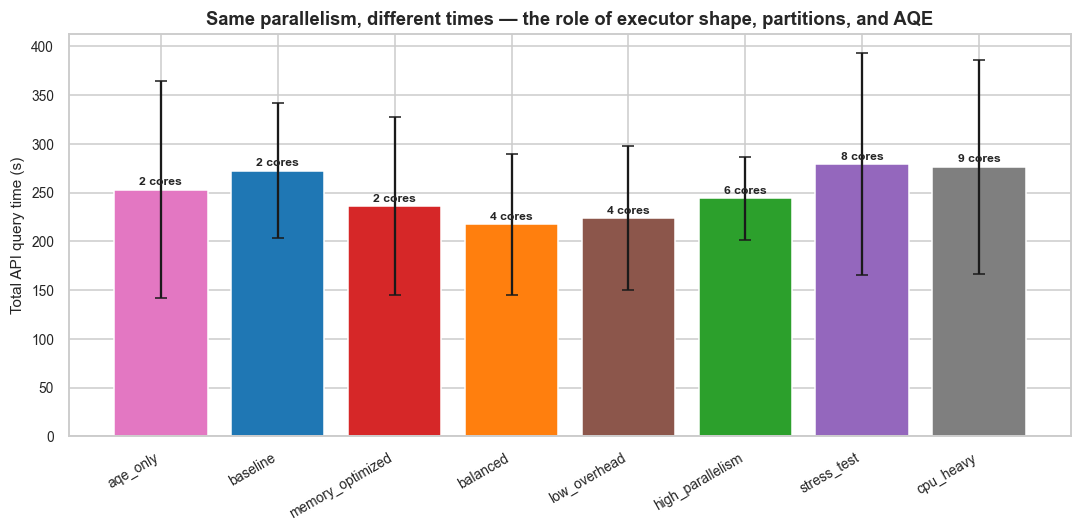

In [19]:
# Group scenarios by total_cores and show the spread
fig, ax = plt.subplots(figsize=(10, 5))

scenarios_sorted = scaling.sort_values("total_cores")["spark_mode"].tolist()
colors = [SCENARIO_PALETTE[s] for s in scenarios_sorted]

bar_data = scaling.sort_values("total_cores")
bars = ax.bar(bar_data["spark_mode"], bar_data["mean_time"],
              yerr=bar_data["std_time"], capsize=4, color=colors, edgecolor="white")

# Annotate with total_cores
for bar, cores in zip(bars, bar_data["total_cores"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"{int(cores)} cores", ha="center", fontsize=8, fontweight="bold")

ax.set_xticklabels(bar_data["spark_mode"], rotation=30, ha="right")
ax.set_ylabel("Total API query time (s)")
ax.set_title("Same parallelism, different times — the role of executor shape, partitions, and AQE")
plt.tight_layout()
plt.show()

## **6. Spark Performance — ML Models**

ML training has very different cost characteristics from queries: it's iterative, weighted toward CPU rather than I/O, and dominated by tree-building (in our case) which is sensitive to executor parallelism.

### **6.1. Training time by scenario and model**

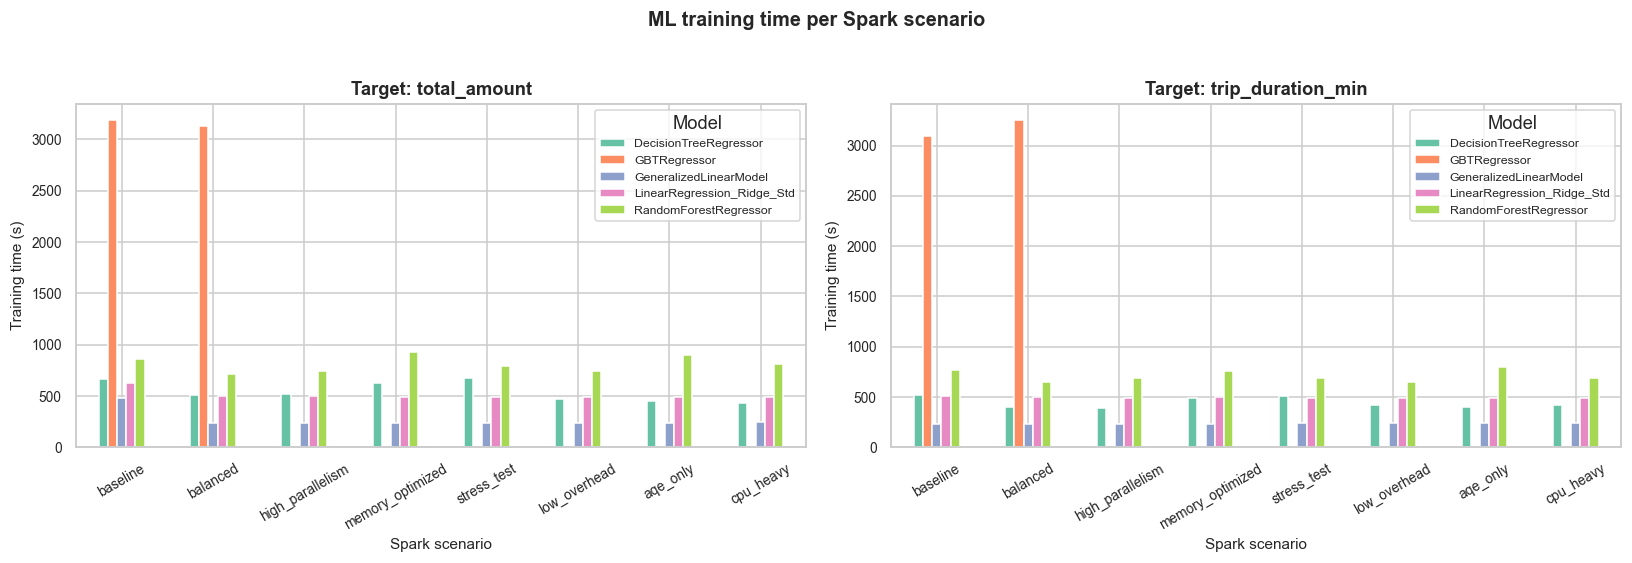

In [20]:
# We aggregate per (model, target, scenario) — keep both targets visible
ml_times = (
    df_models.groupby(["model_name", "target", "spark_mode"])
             .agg(mean_time=("execution_time_seconds", "mean"),
                  std_time=("execution_time_seconds", "std"))
             .reset_index()
)

targets = sorted(df_models["target"].dropna().unique())
fig, axes = plt.subplots(1, len(targets), figsize=(7.5 * len(targets), 5), sharey=False)
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = ml_times[ml_times["target"] == target].copy()
    pivot = sub.pivot(index="spark_mode", columns="model_name", values="mean_time")
    pivot = pivot.reindex([s for s in SCENARIO_ORDER if s in pivot.index])

    pivot.plot(kind="bar", ax=ax, edgecolor="white",
               color=[MODEL_PALETTE.get(m, "#888") for m in pivot.columns])

    ax.set_title(f"Target: {target}")
    ax.set_xlabel("Spark scenario")
    ax.set_ylabel("Training time (s)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Model", fontsize=8, loc="best")

plt.suptitle("ML training time per Spark scenario", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### **6.2. Model cost vs accuracy trade-off**

A natural visualization for choosing a model: plot training time against predictive performance. Top-left = expensive and inaccurate (avoid). Bottom-right = fast and accurate (ideal).

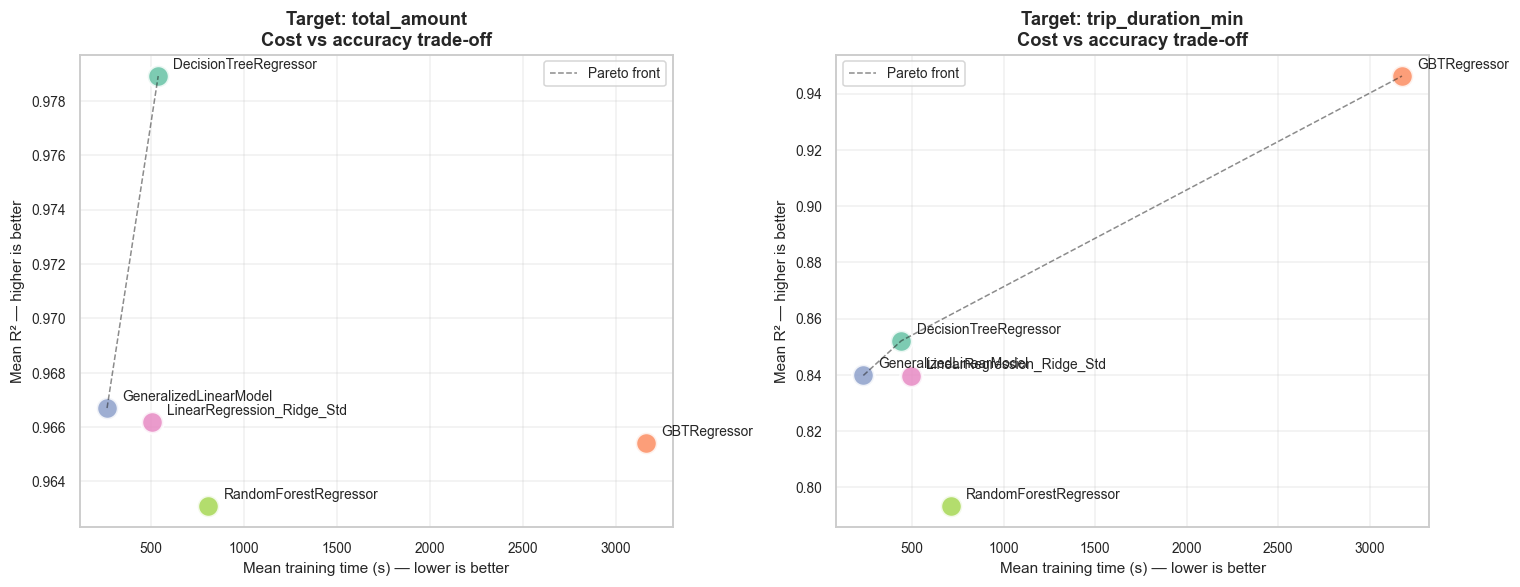

In [21]:
# Use the mean across scenarios for each (model, target)
tradeoff = (
    df_models.groupby(["model_name", "target"])
             .agg(mean_time=("execution_time_seconds", "mean"),
                  mean_r2=("r2", "mean"),
                  mean_rmse=("rmse", "mean"))
             .reset_index()
)

fig, axes = plt.subplots(1, len(targets), figsize=(7 * len(targets), 5.5))
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = tradeoff[tradeoff["target"] == target]
    for _, row in sub.iterrows():
        ax.scatter(row["mean_time"], row["mean_r2"], s=200,
                   color=MODEL_PALETTE.get(row["model_name"], "#888"),
                   edgecolor="white", linewidth=2, alpha=0.85)
        ax.annotate(row["model_name"],
                    (row["mean_time"], row["mean_r2"]),
                    xytext=(10, 5), textcoords="offset points", fontsize=9)

    ax.set_xlabel("Mean training time (s) — lower is better")
    ax.set_ylabel("Mean R² — higher is better")
    ax.set_title(f"Target: {target}\nCost vs accuracy trade-off")
    ax.grid(True, alpha=0.3)

    # Pareto front annotation
    sub_sorted = sub.sort_values("mean_time")
    pareto_pts = []
    best_r2 = -np.inf
    for _, r in sub_sorted.iterrows():
        if r["mean_r2"] > best_r2:
            pareto_pts.append((r["mean_time"], r["mean_r2"]))
            best_r2 = r["mean_r2"]
    if len(pareto_pts) > 1:
        px, py = zip(*pareto_pts)
        ax.plot(px, py, "k--", lw=1, alpha=0.5, label="Pareto front")
        ax.legend()

plt.tight_layout()
plt.show()

## **7. ML Model Comparison — Quality of Predictions**

Each team member trained a different algorithm on the same two regression targets. We now compare them on predictive performance, abstracting away from the Spark configuration used.

### **7.1. Leaderboard per target**

In [22]:
# Best result per (model, target) across all runs
def show_leaderboard(target):
    sub = df_models[df_models["target"] == target].copy()
    leaderboard = (
        sub.groupby("model_name")
           .agg(best_rmse=("rmse", "min"),
                best_r2=("r2", "max"),
                best_mae=("mae", "min"),
                mean_time=("execution_time_seconds", "mean"))
           .sort_values("best_r2", ascending=False)
           .round(4)
    )
    return leaderboard

for target in targets:
    print(f"\n{'='*60}")
    print(f"  TARGET: {target}")
    print(f"{'='*60}")
    print(show_leaderboard(target))


  TARGET: total_amount
                            best_rmse  best_r2  best_mae  mean_time
model_name                                                         
DecisionTreeRegressor          1.6910   0.9816    0.5982   541.2125
GeneralizedLinearModel         2.2707   0.9667    1.2043   266.3775
LinearRegression_Ridge_Std     2.2880   0.9662    1.2109   508.7200
GBTRegressor                   2.3165   0.9654    1.1289  3161.0050
RandomForestRegressor          2.3599   0.9641    1.2600   810.6688

  TARGET: trip_duration_min
                            best_rmse  best_r2  best_mae  mean_time
model_name                                                         
GBTRegressor                   2.3297   0.9462    1.0728  3176.1700
DecisionTreeRegressor          3.8562   0.8531    1.4068   440.9838
GeneralizedLinearModel         4.0182   0.8398    2.3412   233.5662
LinearRegression_Ridge_Std     4.0208   0.8396    2.3487   493.5675
RandomForestRegressor          4.5280   0.7967    2.6526   712.

### **7.2. Metric comparison across models**

Visualizing all four regression metrics side-by-side. For RMSE/MAE/MSE: lower is better. For R²: higher is better.

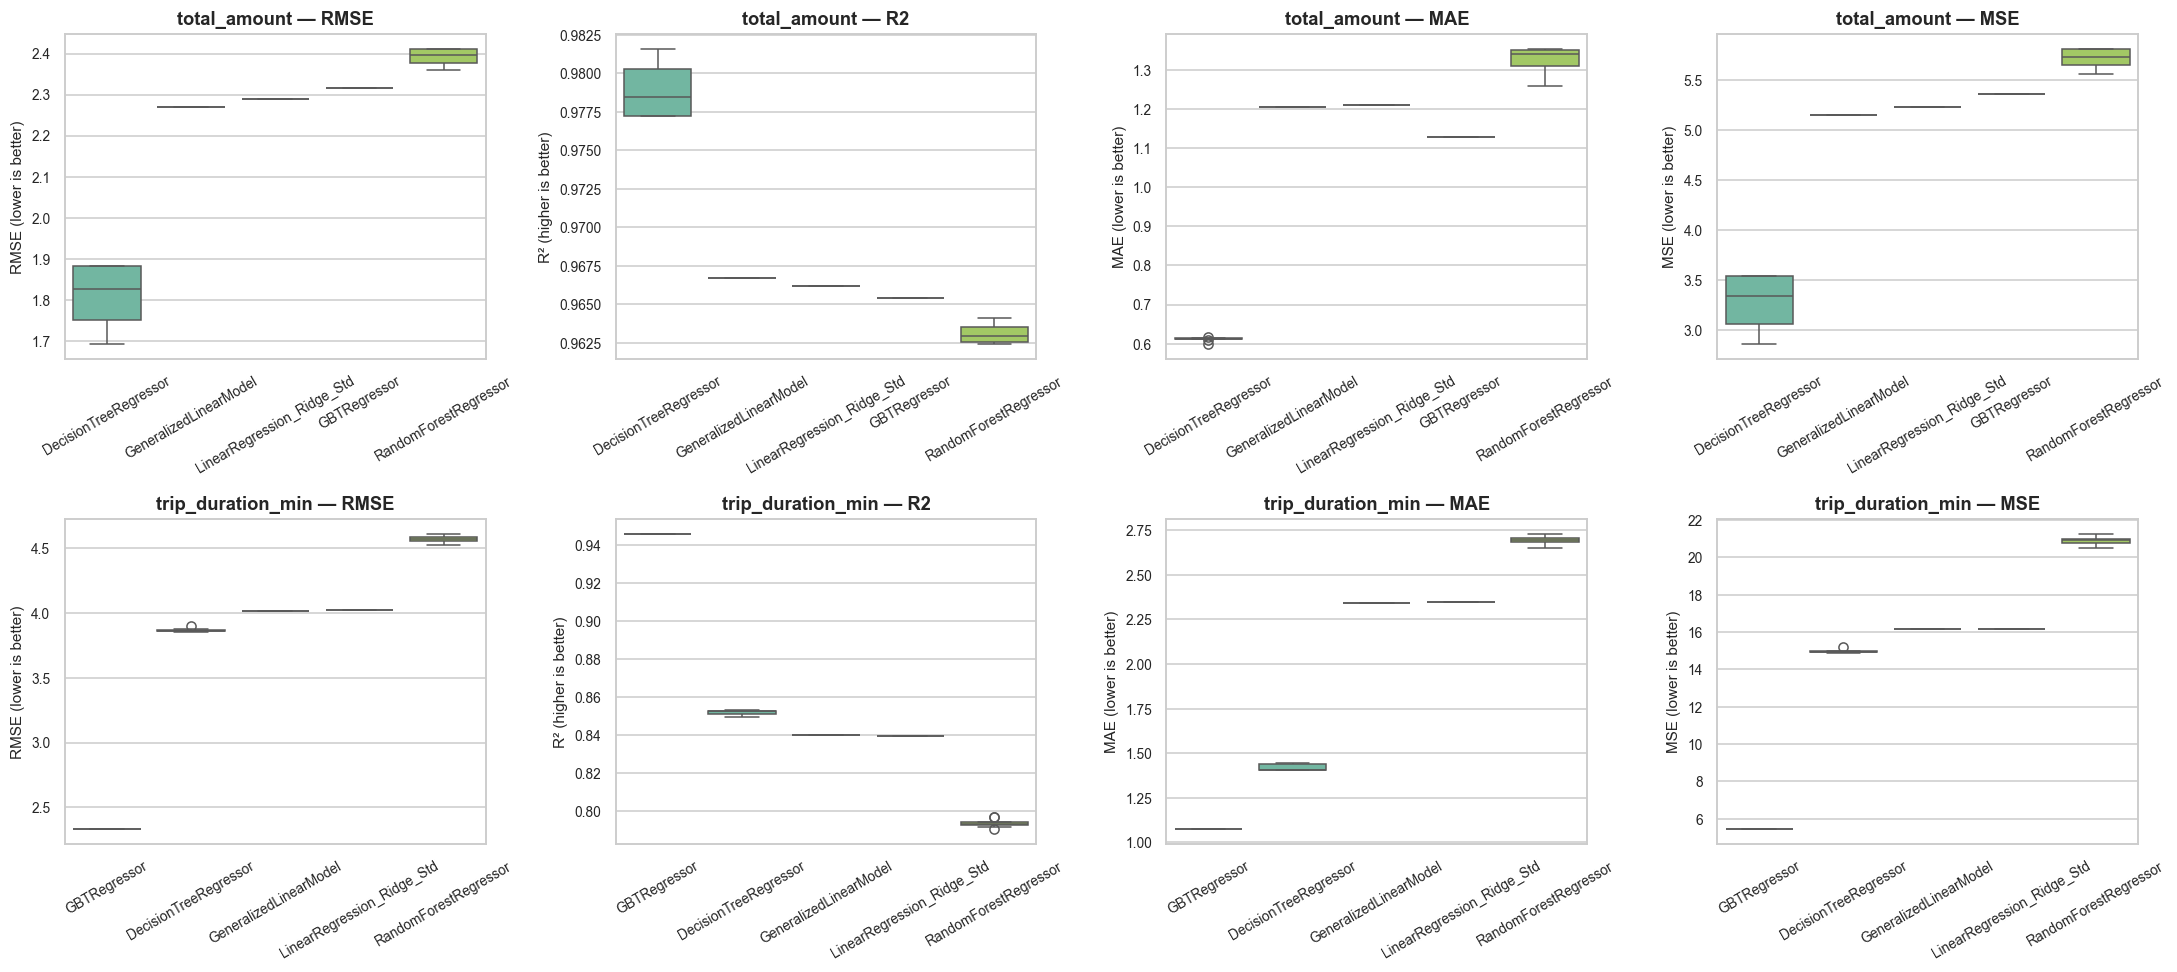

In [23]:
metrics_to_plot = ["rmse", "r2", "mae", "mse"]
n_targets = len(targets)
fig, axes = plt.subplots(n_targets, 4, figsize=(20, 4.5 * n_targets))
if n_targets == 1:
    axes = axes.reshape(1, -1)

for row, target in enumerate(targets):
    sub = df_models[df_models["target"] == target]
    model_order = (sub.groupby("model_name")["r2"].mean()
                      .sort_values(ascending=False).index.tolist())

    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        sns.boxplot(data=sub, x="model_name", y=metric, order=model_order,
                    palette=[MODEL_PALETTE.get(m, "#888") for m in model_order],
                    ax=ax)
        ax.set_title(f"{target} — {metric.upper()}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=30)
        if metric == "r2":
            ax.set_ylabel("R² (higher is better)")
        else:
            ax.set_ylabel(f"{metric.upper()} (lower is better)")

plt.tight_layout()
plt.show()

### **7.3. Stability across Spark scenarios**

A good model is *stable*: its metrics shouldn't depend on the Spark configuration (since the algorithm is the same). Wide bars here suggest either non-determinism or sensitivity to data partitioning (which happens with some algorithms).

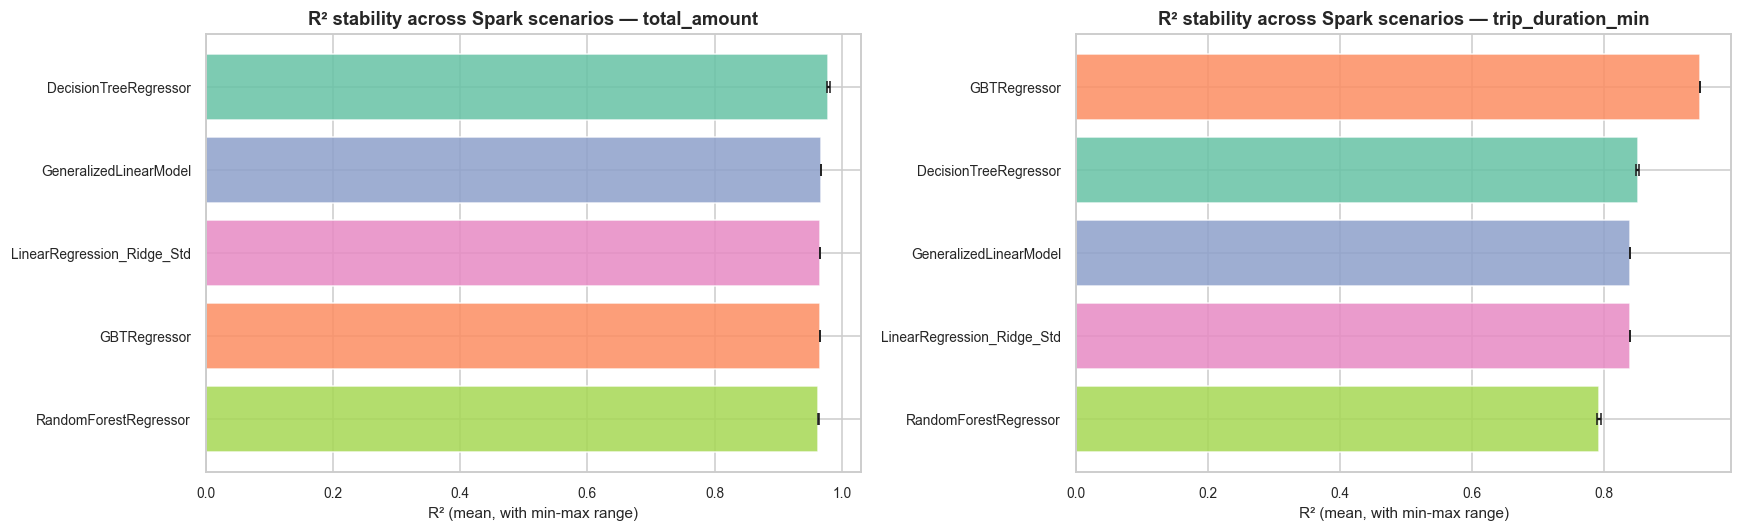

In [24]:
fig, axes = plt.subplots(1, n_targets, figsize=(8 * n_targets, 5))
if n_targets == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = df_models[df_models["target"] == target]
    stability = (sub.groupby("model_name")["r2"]
                    .agg(["mean", "std", "min", "max"])
                    .sort_values("mean", ascending=False))

    y = np.arange(len(stability))
    ax.barh(y, stability["mean"],
            xerr=[stability["mean"] - stability["min"],
                  stability["max"] - stability["mean"]],
            color=[MODEL_PALETTE.get(m, "#888") for m in stability.index],
            edgecolor="white", capsize=4, alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(stability.index)
    ax.set_xlabel("R² (mean, with min-max range)")
    ax.set_title(f"R² stability across Spark scenarios — {target}")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

## **8. Post-Modeling Analysis — Diagnostic Plots**

The JSONs only contain aggregate metrics. For a deeper look at how the model behaves, we need the actual predictions and feature importances. These are produced by running `prediction_luana.ipynb` once with a small export block that saves:

- `predictions_sample.parquet` — a sample of (y_true, y_pred) for both targets
- `feature_importance_total_amount.csv` and `feature_importance_trip_duration.csv`

The code below runs the diagnostics if these files exist, and otherwise prints a helpful message with the export snippet you can paste into the prediction notebook.

### **8.1. Export snippet for the prediction notebook**

Paste this into `prediction_luana.ipynb` after each model is fitted, replacing `_fitted_model` and `_test` with the appropriate variable names. Then run once to generate the artifact files.

```python
# Add to prediction_luana.ipynb (one block per target)
import os
os.makedirs("data/results/artifacts", exist_ok=True)

# ----- total_amount -----
amount_preds_sample = (
    amount_predictions
    .select("total_amount", "prediction")
    .withColumnRenamed("total_amount", "y_true")
    .withColumnRenamed("prediction", "y_pred")
    .withColumn("target", F.lit("total_amount"))
    .sample(fraction=0.01, seed=42)
    .toPandas()
)

# ----- trip_duration -----
duration_preds_sample = (
    duration_predictions
    .select("trip_duration_min", "prediction")
    .withColumnRenamed("trip_duration_min", "y_true")
    .withColumnRenamed("prediction", "y_pred")
    .withColumn("target", F.lit("trip_duration_min"))
    .sample(fraction=0.01, seed=42)
    .toPandas()
)

import pandas as pd
pd.concat([amount_preds_sample, duration_preds_sample]).to_parquet(
    "data/results/artifacts/predictions_sample.parquet"
)

# Feature importance — works for tree-based models (RF, DT, GBT)
def export_importance(fitted_pipeline, assembler_inputs, path):
    rf = fitted_pipeline.stages[-1]
    importances = rf.featureImportances.toArray()
    pd.DataFrame({
        "feature": assembler_inputs,
        "importance": importances
    }).sort_values("importance", ascending=False).to_csv(path, index=False)

export_importance(amount_fitted_model, assembler_inputs,
                  "data/results/artifacts/feature_importance_total_amount.csv")
export_importance(duration_model_fitted, assembler_inputs,
                  "data/results/artifacts/feature_importance_trip_duration.csv")
```

### **8.2. Predicted vs Actual + residuals**

The diagnostic plot par excellence for any regression model. We want:
- Predictions hugging the y=x diagonal
- Residuals centered around zero with constant variance (no funnel shape = no heteroscedasticity)

In [ ]:
def plot_diagnostics(df_preds, target_name):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    y_true = df_preds["y_true"]
    y_pred = df_preds["y_pred"]
    residuals = y_true - y_pred

    # (a) Predicted vs Actual
    lim = max(y_true.max(), y_pred.max())
    axes[0].scatter(y_true, y_pred, alpha=0.3, s=12, color="#4C72B0", edgecolor="none")
    axes[0].plot([0, lim], [0, lim], "k--", lw=1.2, label="y = x (perfect)")
    axes[0].set_xlabel(f"Actual {target_name}")
    axes[0].set_ylabel(f"Predicted {target_name}")
    axes[0].set_title("Predicted vs Actual")
    axes[0].legend(fontsize=8)

    # (b) Residuals vs predicted
    axes[1].scatter(y_pred, residuals, alpha=0.3, s=12, color="#55A868", edgecolor="none")
    axes[1].axhline(0, color="black", linestyle="--", lw=1)
    axes[1].set_xlabel(f"Predicted {target_name}")
    axes[1].set_ylabel("Residual (actual - predicted)")
    axes[1].set_title("Residuals vs Predicted")

    # (c) Distribution of residuals
    axes[2].hist(residuals, bins=60, color="#DD8452", edgecolor="white")
    axes[2].axvline(0, color="black", linestyle="--", lw=1)
    axes[2].axvline(residuals.mean(), color="red", linestyle="-", lw=1.5,
                    label=f"mean = {residuals.mean():.2f}")
    axes[2].set_xlabel("Residual")
    axes[2].set_ylabel("Frequency")
    axes[2].set_title("Residual distribution")
    axes[2].legend(fontsize=8)

    plt.suptitle(f"Diagnostic plots — {target_name}", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\nResidual statistics for {target_name}:")
    print(f"  Mean:    {residuals.mean():.3f} (should be ≈ 0)")
    print(f"  Std:     {residuals.std():.3f}")
    print(f"  |Max|:   {residuals.abs().max():.3f}")
    print(f"  % of |residual| > 2σ: {(residuals.abs() > 2*residuals.std()).mean()*100:.1f}%")


if os.path.exists(PREDICTIONS_SAMPLE_PATH):
    preds = pd.read_parquet(PREDICTIONS_SAMPLE_PATH)
    for target in preds["target"].unique():
        plot_diagnostics(preds[preds["target"] == target], target)
else:
    print("⚠️  Predictions sample not found.")
    print(f"   Expected at: {PREDICTIONS_SAMPLE_PATH}")
    print("   See section 8.1 above for the export snippet to add to prediction_luana.ipynb.")

### **8.3. Feature importance**

For a tree-based model (Random Forest, Decision Tree, GBT), feature importance tells us which inputs drove the predictions. It's measured as the total impurity decrease attributable to splits on each feature.

In [ ]:
def plot_importance(path, target_name):
    if not os.path.exists(path):
        print(f"⚠️  Feature importance file not found at {path}")
        print("   See section 8.1 for the export snippet.")
        return

    imp = pd.read_csv(path).sort_values("importance", ascending=True)
    imp = imp[imp["importance"] > 0].tail(15)  # top 15

    fig, ax = plt.subplots(figsize=(9, max(3.5, 0.35 * len(imp))))
    ax.barh(imp["feature"], imp["importance"], color="#4C72B0", edgecolor="white")
    ax.set_xlabel("Importance (impurity decrease)")
    ax.set_title(f"Feature importance — {target_name}")
    for i, v in enumerate(imp["importance"]):
        ax.text(v + imp["importance"].max() * 0.01, i, f"{v:.3f}",
                va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

plot_importance(FEATURE_IMPORTANCE_AMOUNT_PATH, "total_amount")
plot_importance(FEATURE_IMPORTANCE_DURATION_PATH, "trip_duration_min")

### **8.4. Error analysis — where does the model fail?**

Looking at *which* predictions are worst, not just on average, often reveals systematic issues (e.g. the model breaks down on long trips, or on high-fare outliers).

In [ ]:
if os.path.exists(PREDICTIONS_SAMPLE_PATH):
    preds = pd.read_parquet(PREDICTIONS_SAMPLE_PATH)
    preds["abs_error"] = (preds["y_true"] - preds["y_pred"]).abs()
    preds["rel_error"] = preds["abs_error"] / preds["y_true"].replace(0, np.nan)

    fig, axes = plt.subplots(1, len(preds["target"].unique()),
                              figsize=(7 * len(preds["target"].unique()), 5))
    if len(preds["target"].unique()) == 1:
        axes = [axes]

    for ax, target in zip(axes, preds["target"].unique()):
        sub = preds[preds["target"] == target].copy()

        # Bin actuals into quintiles, look at the error in each bin
        sub["bucket"] = pd.qcut(sub["y_true"], q=5, duplicates="drop")
        error_by_bucket = sub.groupby("bucket", observed=True).agg(
            mean_abs_err=("abs_error", "mean"),
            median_abs_err=("abs_error", "median"),
            count=("abs_error", "count"),
        ).reset_index()

        bucket_labels = [f"{interval.left:.0f}–{interval.right:.0f}"
                         for interval in error_by_bucket["bucket"]]

        x = np.arange(len(error_by_bucket))
        ax.bar(x, error_by_bucket["mean_abs_err"], color="#C44E52",
               edgecolor="white", label="Mean |error|")
        ax.plot(x, error_by_bucket["median_abs_err"], "o-",
                color="black", lw=1.5, label="Median |error|")
        ax.set_xticks(x)
        ax.set_xticklabels(bucket_labels, rotation=30, ha="right")
        ax.set_xlabel(f"{target} (quintile bin)")
        ax.set_ylabel("Absolute error")
        ax.set_title(f"Error by target magnitude — {target}")
        ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Skipping error analysis (predictions sample not found).")

## **9. Consolidated Findings**

Below we compute the key numbers the report can cite directly. Everything is dynamic — re-running this cell after adding more results will update the figures.

In [ ]:
print("=" * 70)
print("  CONSOLIDATED FINDINGS")
print("=" * 70)

# Best scenario for queries
best_q_scenario = scenario_summary["api_mean"].idxmin()
worst_q_scenario = scenario_summary["api_mean"].idxmax()
ratio_q = scenario_summary.loc[worst_q_scenario, "api_mean"] / scenario_summary.loc[best_q_scenario, "api_mean"]

print(f"\n[Queries]")
print(f"  Fastest scenario: {best_q_scenario} ({scenario_summary.loc[best_q_scenario, 'api_mean']:.1f}s)")
print(f"  Slowest scenario: {worst_q_scenario} ({scenario_summary.loc[worst_q_scenario, 'api_mean']:.1f}s)")
print(f"  Worst/best ratio: {ratio_q:.2f}×")

# AQE effect
if "aqe_only" in scenario_summary.index and "baseline" in scenario_summary.index:
    aqe_effect = scenario_summary.loc['baseline', 'api_mean'] / scenario_summary.loc['aqe_only', 'api_mean']
    print(f"  AQE speedup (baseline → aqe_only): {aqe_effect:.2f}×")

# Scaling
max_speedup = scaling["speedup"].max()
max_speedup_scenario = scaling.loc[scaling["speedup"].idxmax(), "spark_mode"]
print(f"\n[Scaling]")
print(f"  Maximum measured speedup: {max_speedup:.2f}× ({max_speedup_scenario})")
print(f"  Estimated serial fraction: {mean_f:.3f}")
print(f"  Implied Amdahl ceiling: ~{1/max(mean_f, 0.01):.1f}×")

# ML best models
print(f"\n[ML Models]")
for target in targets:
    sub = df_models[df_models["target"] == target]
    leader = sub.groupby("model_name")["r2"].mean().idxmax()
    leader_r2 = sub.groupby("model_name")["r2"].mean().max()
    leader_rmse = sub.groupby("model_name")["rmse"].mean().min()
    print(f"  {target}: best R² = {leader_r2:.4f} ({leader})")

print(f"\n[ML Training Time]")
print(f"  Fastest model on average: "
      f"{df_models.groupby('model_name')['execution_time_seconds'].mean().idxmin()}")
print(f"  Slowest model on average: "
      f"{df_models.groupby('model_name')['execution_time_seconds'].mean().idxmax()}")

---

## **10. Notes for the Report**

Drawing on the figures above, the report's *Runtime/performance* and *Results analysis* sections can structure their narrative around:

1. **The configuration space matters more than raw core count.** Figure 5.3 shows that scenarios with the same `total_cores` can differ by a large margin in execution time. This is the cleanest empirical evidence for "tuning > scaling" on workloads of this size.

2. **AQE delivers consistent but modest gains.** The isolated comparison in §4.4 cleanly attributes the speedup to Adaptive Query Execution alone, with baseline as the only difference.

3. **Strong scaling is sub-linear, bounded by Amdahl's Law.** Section 5 quantifies how much of the workload is inherently serial (driver coordination, shuffles, result collection). This is a fundamental property of the workload, not a Spark deficiency.

4. **Cluster constraints shape the experimental space.** The `cpu_heavy` scenario could not be executed because `executor_cores=3` exceeds the YARN limit on `n2-standard-2` workers. This is itself a finding worth documenting in the report.

5. **Model choice is a Pareto problem.** Section 6.2's cost-accuracy plot shows that the "best" model depends on whether you optimize for training time, predictive accuracy, or some weighted combination.

---